PRÁCTICA MACHINE LEARNING: Predecir el mercado de valores

 ¡Hola y bienvenido a la Práctica de Machine Learning más difícil del mundo!

Este notebook está diseñado para ayudarte a comenzar con la práctica.

En este cuaderno vamos a:

- Descargar y explorar el conjunto de datos
- Entrenar y evaluar este primer modelo de aprendizaje automático
- Implementar el modelo para comenzar a realizar predicciones

# 1.- DATASET

A alto nivel, trabajaremos con un conjunto de datos tabulares que describe el mercado de valores a lo largo del tiempo.

Cada fila representa una acción en un momento específico, donde "id" es la identificación de la acción y "era" es la fecha. 

Las características describen los atributos de la acción (por ejemplo, el ratio Price/Earning) conocidos en una fecha dada, y "target" es una medida de rendimientos a 20 días.

El conjunto de datos está ofuscado, lo que significa que los identificadores de acciones (stocks) subyacentes, los nombres de las características y las definiciones de objetivos son anónimos. Esto hace que podamos trabajar con estos datos de forma gratuita y que puedan modelarse sin ningún conocimiento (¡o sesgo!) del dominio financiero.

Descargamos los datos históricos de entrenamiento y echamos un vistazo de cerca.


# Inicializamos la API oficial de Numerai para descargar los conjuntos de datos más recientes.

In [1]:
# Inicializa NumerAPI - el cliente oficial de Python para acceder al API de nuestro conjunto de datos.
from numerapi import NumerAPI
napi = NumerAPI()

# Set data version to one of the latest datasets
DATA_VERSION = "v5.0"

# Imprime todos los ficheros del conjunto de datos disponibles para descargar los más recientes.
[f for f in napi.list_datasets() if f.startswith(DATA_VERSION)]

['v5.0/features.json',
 'v5.0/live.parquet',
 'v5.0/live_benchmark_models.parquet',
 'v5.0/live_example_preds.csv',
 'v5.0/live_example_preds.parquet',
 'v5.0/meta_model.parquet',
 'v5.0/train.parquet',
 'v5.0/train_benchmark_models.parquet',
 'v5.0/validation.parquet',
 'v5.0/validation_benchmark_models.parquet',
 'v5.0/validation_example_preds.csv',
 'v5.0/validation_example_preds.parquet']

# Descarga de datos de Entrenamiento
Descargamos los archivos necesarios (entrenamiento y metadatos de características).

In [2]:
import pandas as pd
import json

# Descarga los datos de entrenamiento y los metadatos de las características
# Esto tomará unos pocos minutos 🍵
napi.download_dataset(f"{DATA_VERSION}/train.parquet");
napi.download_dataset(f"{DATA_VERSION}/features.json");

# Carga solo el conjunto de features "medium" para reducir el uso de memoria y acelerar el entrenamiento del modelo 
# O bien, utiliza el conjunto de features "all" para usar todas las características
# En este ejemplo descargaremos solo el "small"
feature_metadata = json.load(open(f"{DATA_VERSION}/features.json"))
feature_sets = feature_metadata["feature_sets"]
for feature_set in ["small", "medium", "all"]:
  print(feature_set, len(feature_sets[feature_set]))

feature_set = feature_sets["small"]
#feature_cols = feature_metadata["feature_sets"]["small"]
#train = pd.read_parquet(f"{DATA_VERSION}/train.parquet", columns=["era"] + feature_cols + ["target"])
train = pd.read_parquet(
    f"{DATA_VERSION}/train.parquet",
    columns=["era", "target"] + feature_set
)

# Reduce la muestra, tomando cada cuatro eras, para reducir el uso de memoria y acelerar el entrenamiento del modelo (toma las eras 0001, 0005, 0009, ...)
# Comenta la línea a continuación para utilizar todos los datos.
train = train[train["era"].isin(train["era"].unique()[::4])]
train

2025-11-07 12:18:01,074 INFO numerapi.utils: target file already exists
2025-11-07 12:18:01,075 INFO numerapi.utils: download complete
2025-11-07 12:18:02,567 INFO numerapi.utils: target file already exists
2025-11-07 12:18:02,568 INFO numerapi.utils: download complete


small 42
medium 705
all 2376


,era,target,feature_antistrophic_striate_conscriptionist,feature_bicameral_showery_wallaba,feature_bridal_fingered_pensioner,feature_collectivist_flaxen_gueux,feature_concurring_fabled_adapter,feature_crosscut_whilom_ataxy,feature_departmental_inimitable_sentencer,feature_dialectal_homely_cambodia,...,feature_tridactyl_immoral_snorting,feature_trimeter_soggy_greatest,feature_unanalyzable_excusable_whirlwind,feature_unbreakable_constraining_hegelianism,feature_unformed_bent_smatch,feature_unministerial_unextenuated_teleostean,feature_unmodish_zymogenic_rousing,feature_unsystematized_subcardinal_malaysia,feature_willful_sere_chronobiology,feature_zoological_peristomial_scute
id,,,,,,,,,,,,,,,,,,,,,
n0007b5abb0c3a25,0001,0.25,2,2,2,2,2,0,1,2,...,4,1,1,3,0,2,2,3,3,2
n003bba8a98662e4,0001,0.25,2,2,2,2,2,1,4,2,...,4,2,0,0,0,2,2,4,4,2
n003bee128c2fcfc,0001,0.75,2,2,2,2,2,2,2,2,...,3,1,1,0,1,2,2,0,3,2
n0048ac83aff7194,0001,0.25,2,2,2,2,2,1,4,2,...,1,3,4,1,2,2,2,2,0,2
n0055a2401ba6480,0001,0.25,2,2,2,2,2,0,0,2,...,1,0,1,0,0,2,2,1,4,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
nffc2d5e4b79a7ae,0573,0.00,1,2,1,0,3,2,1,1,...,2,2,1,2,3,3,3,2,2,1
nffc9844c1c7a6a9,0573,0.25,2,1,2,1,4,2,2,4,...,4,0,0,3,1,3,3,2,3,2
nffd79773f4109bb,0573,0.50,3,4,0,3,4,1,0,1,...,3,0,0,0,1,1,4,0,1,2


ERAS:

Como se mencionó anteriormente, cada "era" corresponde a una fecha diferente. Cada "era" tiene exactamente una semana de diferencia.

Es útil pensar en filas de acciones dentro de la misma "era" como un solo ejemplo. A lo largo de este notebook hablaremos de cosas "por era". Por ejemplo, el número de filas por "era" representa el conjunto de acciones (stocks) dentro de las posibilidades de inversión de algún fondo en esa fecha.


Visualizamos cuántas observaciones existen en cada era (semana).

 Exploración inicial del dataset
Revisamos la estructura general, tipos de datos y uso de memoria del conjunto de entrenamiento.

In [3]:
# Información básica: tamaño, tipos de datos, memoria
print(train.info())

<class 'pandas.core.frame.DataFrame'>
Index: 688184 entries, n0007b5abb0c3a25 to nfff87b21e4db902
Data columns (total 44 columns):
 #   Column                                         Non-Null Count   Dtype  
---  ------                                         --------------   -----  
 0   era                                            688184 non-null  object 
 1   target                                         688184 non-null  float32
 2   feature_antistrophic_striate_conscriptionist   688184 non-null  int8   
 3   feature_bicameral_showery_wallaba              688184 non-null  int8   
 4   feature_bridal_fingered_pensioner              688184 non-null  int8   
 5   feature_collectivist_flaxen_gueux              688184 non-null  int8   
 6   feature_concurring_fabled_adapter              688184 non-null  int8   
 7   feature_crosscut_whilom_ataxy                  688184 non-null  int8   
 8   feature_departmental_inimitable_sentencer      688184 non-null  int8   
 9   feature_dialectal

In [4]:
# Primeras filas
print(train.head())


                   era  target  feature_antistrophic_striate_conscriptionist  \
id                                                                             
n0007b5abb0c3a25  0001    0.25                                             2   
n003bba8a98662e4  0001    0.25                                             2   
n003bee128c2fcfc  0001    0.75                                             2   
n0048ac83aff7194  0001    0.25                                             2   
n0055a2401ba6480  0001    0.25                                             2   

                  feature_bicameral_showery_wallaba  \
id                                                    
n0007b5abb0c3a25                                  2   
n003bba8a98662e4                                  2   
n003bee128c2fcfc                                  2   
n0048ac83aff7194                                  2   
n0055a2401ba6480                                  2   

                  feature_bridal_fingered_pensioner  

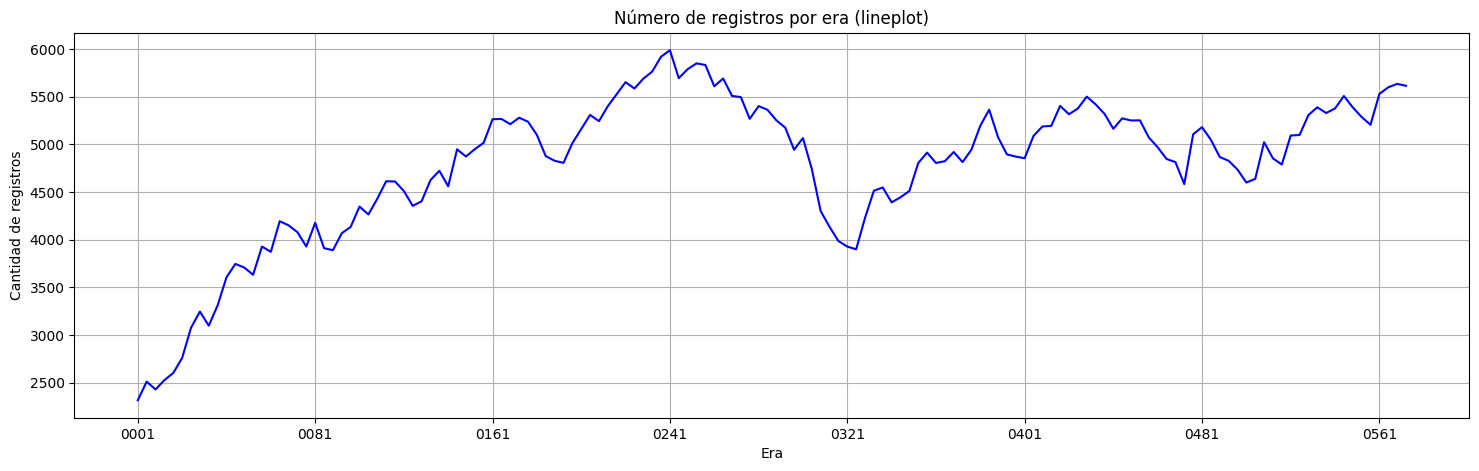

Media de registros por era: 4779.055555555556
Mediana de registros por era: 4944.5
Mínimo registros por era: 2316
Máximo registros por era: 5988


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Número de registros por era
era_counts = train['era'].value_counts().sort_index()

# Lineplot (tendencia a lo largo del tiempo)
plt.figure(figsize=(18,5))
era_counts.plot(kind='line', color='blue')
plt.title("Número de registros por era (lineplot)")
plt.xlabel("Era")
plt.ylabel("Cantidad de registros")
plt.grid(True)
plt.show()

# Estadísticas resumidas
print("Media de registros por era:", era_counts.mean())
print("Mediana de registros por era:", era_counts.median())
print("Mínimo registros por era:", era_counts.min())
print("Máximo registros por era:", era_counts.max())


- Algunas features tienen 6000+ datos históricos 
- Otras features tienen solo 2500 datos 


Visualizamos cuántas observaciones existen en cada era (semana).

In [6]:
print("Número de eras únicas:", train['era'].nunique())
print("Número de registros por era:")
print(train.groupby('era').size())

Número de eras únicas: 144
Número de registros por era:
era
0001    2316
0005    2511
0009    2429
0013    2527
0017    2602
        ... 
0557    5206
0561    5530
0565    5599
0569    5635
0573    5615
Length: 144, dtype: int64


FEATURES:

Como se mencionó anteriormente, las características son atributos cuantitativos de cada acción: fundamentos como la relación P/E (precio/beneficio), señales técnicas como el RSI, datos de mercado como el interés a corto, datos secundarios como las calificaciones de los analistas y mucho más.

La definición subyacente de cada característica no es importante, solo debes saber que se han incluido estas características en el conjunto de datos porque se cree que pueden ser relevantes para predecir el "target".

In [7]:
# Número de características
len(feature_set)

42

# Correlacion entre features

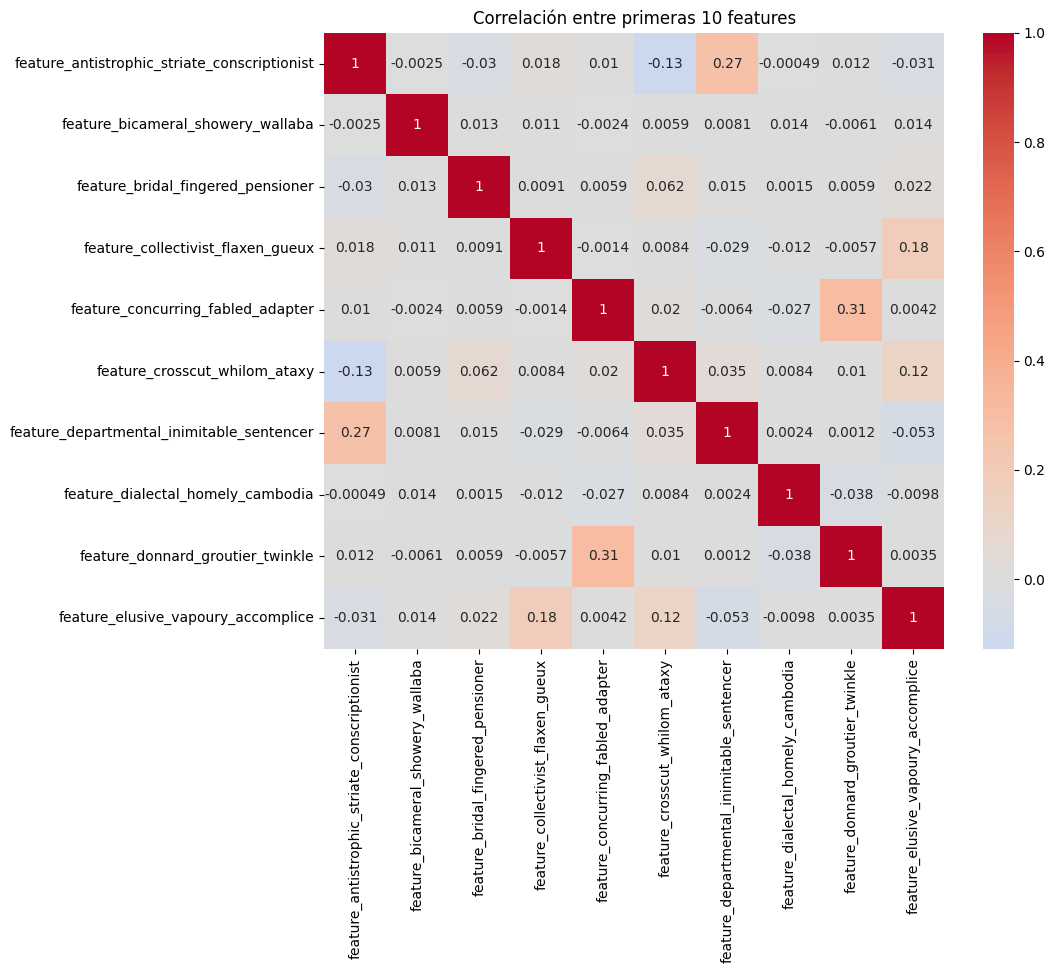

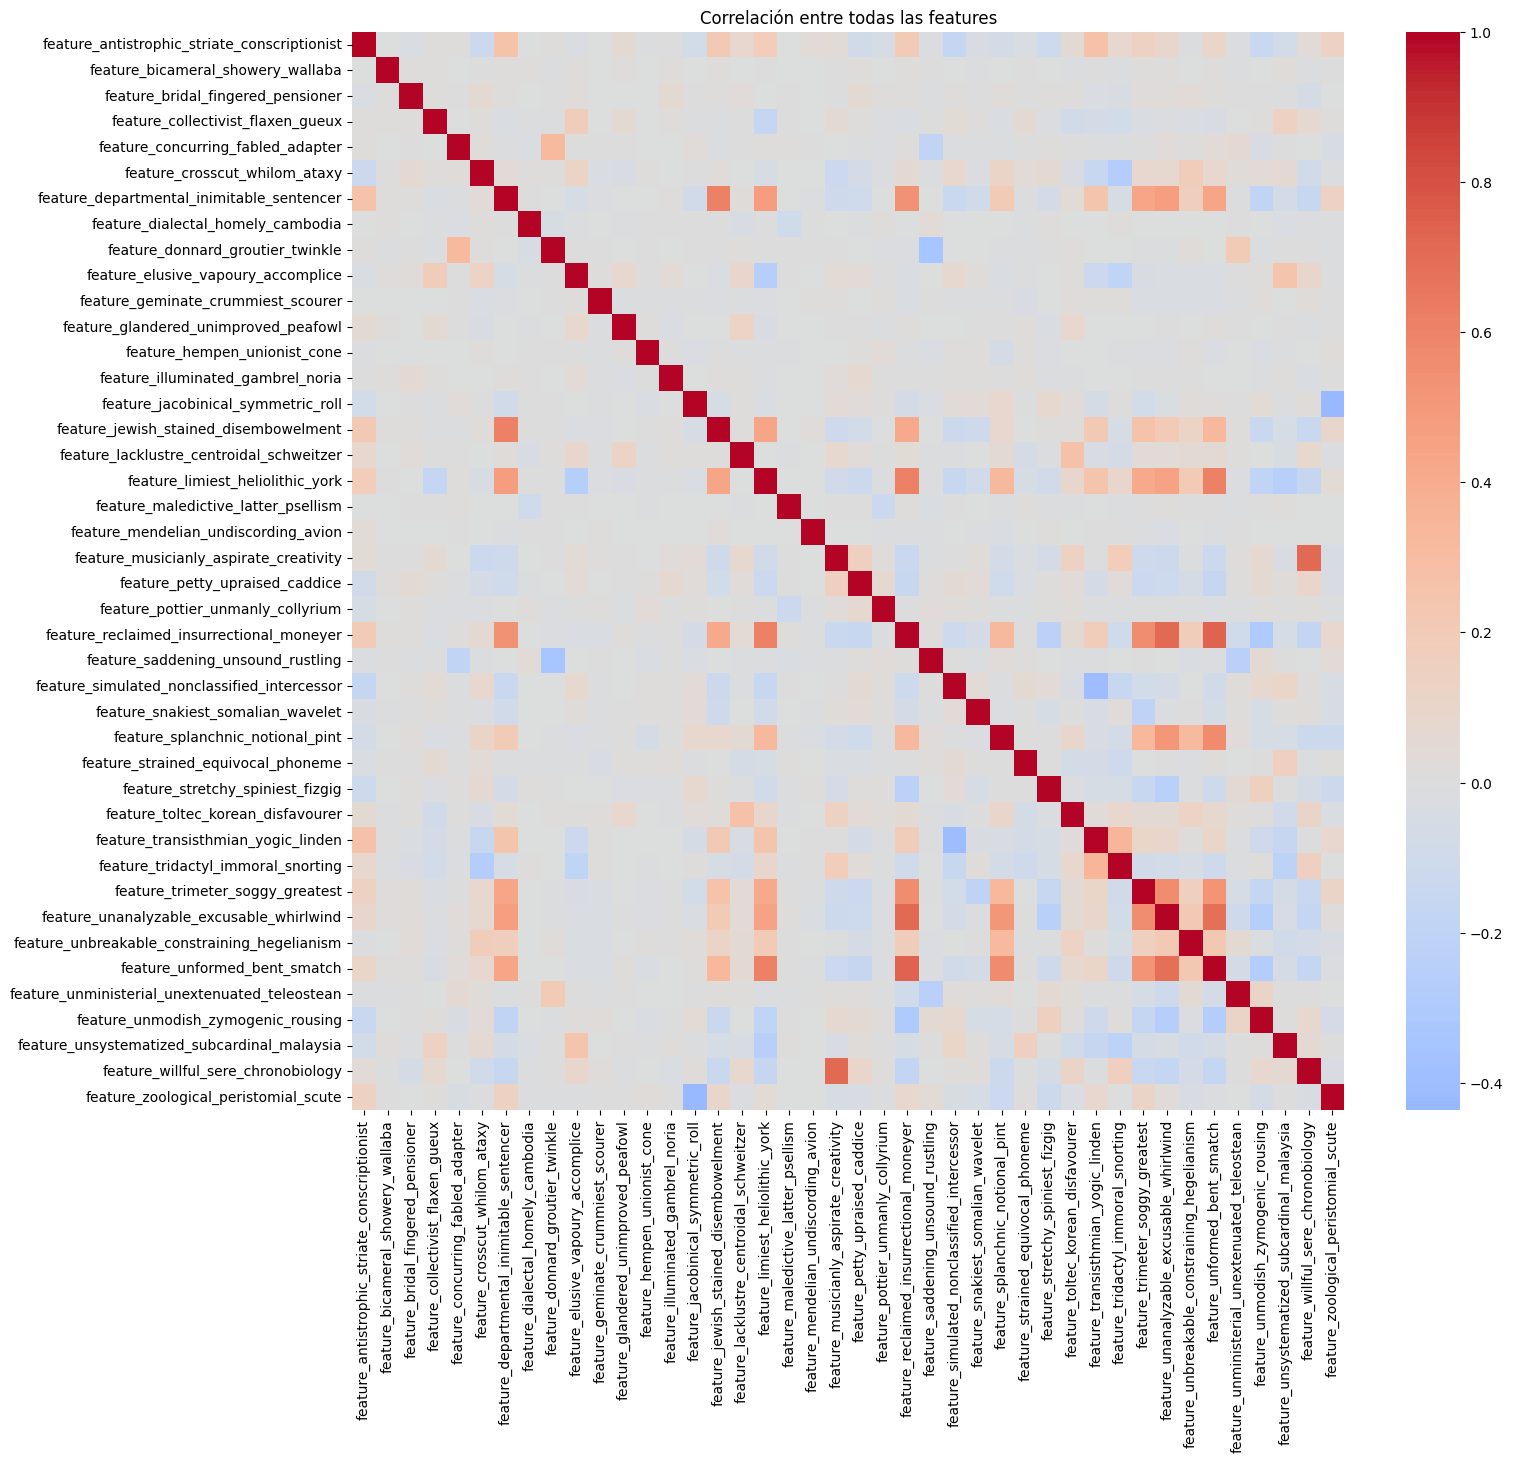

In [8]:

import numpy as np

# Subconjunto de features para visualización
feature_cols = train.columns[2:]  # todas las features
subset_features = feature_cols[:10]  # primeras 10 para no saturar gráficos




# Heatmap de correlación entre features
plt.figure(figsize=(10,8))
sns.heatmap(train[subset_features].corr(), cmap='coolwarm', center=0, annot=True)
plt.title("Correlación entre primeras 10 features")
plt.show()

plt.figure(figsize=(16,14))
corr_matrix = train[feature_cols].corr()

sns.heatmap(corr_matrix, cmap='coolwarm', center=0)
plt.title("Correlación entre todas las features")
plt.show()





Los valores de las características se agrupan en 5 contenedores iguales: 0, 1, 2, 3, 4. Esta fuerte estandarización de los valores de las características tiene como objetivo evitar el overfitting, ya que los valores subyacentes son extremadamente ruidosos.

Si faltan datos de una característica particular para esa era (más común en las primeras eras), todos los valores se establecen en 2.


TARGET:

El "target" es una medida de los rendimientos del mercado de valores a 20 días. Específicamente, es una medida de rendimientos "específicos de acciones" que no se "explican" por tendencias más amplias en el mercado, país, sector o "factores" bien conocidos.

Los valores del "target" se agrupan en 5 contenedores desiguales: 0, 0,25, 0,5, 0,75, 1,0. Nuevamente, esta fuerte estandarización de los valores de target tiene como objetivo evitar el overfitting, ya que los valores subyacentes son extremadamente ruidosos.

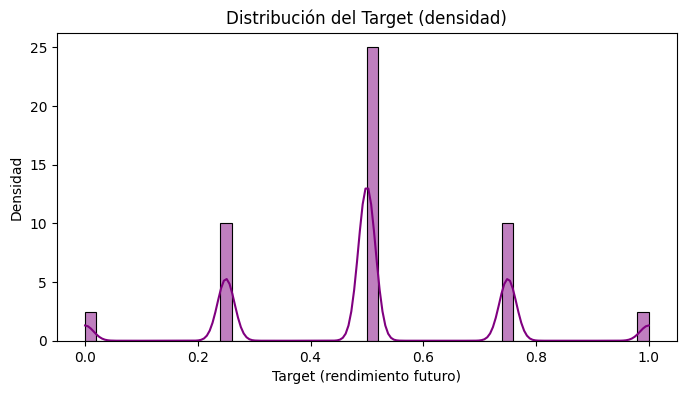

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,4))
sns.histplot(train["target"], bins=50, kde=True, color="purple", stat="density")
plt.title("Distribución del Target (densidad)")
plt.xlabel("Target (rendimiento futuro)")
plt.ylabel("Densidad")
plt.show()


Distribución relativamente balanceada entre las categorías

Picos en los extremos (0.0 y 1.0) → Mercado tiende a movimientos fuertes

Valores intermedios bien representados → Gradiente de performance

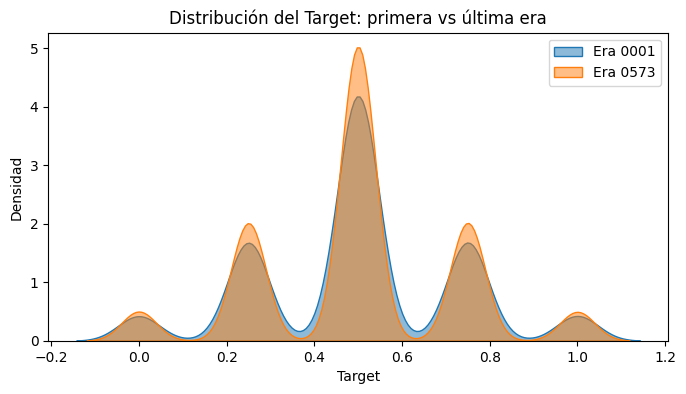

In [10]:
first_era = train['era'].unique()[0]
last_era = train['era'].unique()[-1]

plt.figure(figsize=(8,4))
sns.kdeplot(train[train['era']==first_era]['target'], label=f"Era {first_era}", fill=True, alpha=0.5)
sns.kdeplot(train[train['era']==last_era]['target'], label=f"Era {last_era}", fill=True, alpha=0.5)
plt.title("Distribución del Target: primera vs última era")
plt.xlabel("Target")
plt.ylabel("Densidad")
plt.legend()
plt.show()


- Distribuciones MUY similares en forma general
- Mismos 5 picos en los bins del target (0, 0.25, 0.5, 0.75, 1.0)
- Ligera diferencia en densidades/alturas de los picos

# PCA

In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import numpy as np

# Escalado
X = train[feature_cols].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)
var_explained = np.cumsum(pca.explained_variance_ratio_)
n_components = np.argmax(var_explained >= 0.95) + 1
print("Número de componentes para 95% de varianza:", n_components)


Número de componentes para 95% de varianza: 36


# 2.- MODELING

Entrenamiento del modelo:

Eres libre de utilizar cualquier algoritmo visto en clase. Pero, en este ejemplo, usaremos LGBMRegressor, basado en árboles de decisión para predecir variables continuas. Es una opción popular para las predicciones de este tipo.

In [12]:
from sklearn.model_selection import train_test_split

# Ordenamos eras cronológicamente
eras_sorted = sorted(train['era'].unique())

# Usamos 80% primeras eras para entrenamiento, 20% últimas para test
split_index = int(0.8 * len(eras_sorted))
train_eras = eras_sorted[:split_index]
test_eras = eras_sorted[split_index:]

X_train = train[train['era'].isin(train_eras)][feature_set]
y_train = train[train['era'].isin(train_eras)]['target']

X_test = train[train['era'].isin(test_eras)][feature_set]
y_test = train[train['era'].isin(test_eras)]['target']

print("Eras de entrenamiento:", len(train_eras))
print("Eras de test:", len(test_eras))






Eras de entrenamiento: 115
Eras de test: 29


In [13]:
import lightgbm as lgb

model = lgb.LGBMRegressor(
    n_estimators=2000,
    learning_rate=0.01,
    max_depth=5,
    num_leaves=2**5-1,
    colsample_bytree=0.1
)

model.fit(X_train, y_train)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002667 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 210
[LightGBM] [Info] Number of data points in the train set: 539937, number of used features: 42
[LightGBM] [Info] Start training from score 0.500029


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,5
,learning_rate,0.01
,n_estimators,2000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [14]:
from sklearn.metrics import mean_squared_error
import numpy as np

y_pred = model.predict(X_test)

corr = np.corrcoef(y_test, y_pred)[0,1]
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Correlación (Corr) en test:", corr)
print("RMSE en test:", rmse)


Correlación (Corr) en test: 0.03438327310736996
RMSE en test: 0.2229622575354021


In [15]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=64,
    max_depth=7,
    random_state=42
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

corr_rf = np.corrcoef(y_test, y_pred_rf)[0,1]
print("Correlación (Corr) Random Forest:", corr_rf)


Correlación (Corr) Random Forest: 0.030136887797078057



### Justificacion: RandomForestRegressor

 Se seleccionó -RandomForestRegressor- como uno de los modelos principales debido a su capacidad para manejar -relaciones no lineales, alta dimensionalidad y datos ruidosos-, características propias de los datasets financieros.

#### 1. -Naturaleza de los datos-

- Los datos del mercado de valores son -altamente no lineales-, -ruidosos- y con -distribuciones no estacionarias-.
- En este tipo de entornos, la relación entre las “features” y el “target” cambia con el tiempo y rara vez sigue una función lineal estable.
- Un modelo lineal como Regresión Lineal puede ser demasiado rígido y no capturar esas interacciones complejas entre variables.

#### Ventajas de Random Forest

  - Captura interacciones no lineales entre variables.
  - Es robusto al ruido y outliers.
  - Requiere poca preparación de datos(no necesita escalado ni normalización).
  - Reduce la varianza mediante el promediado de múltiples árboles, evitando overfitting excesivo.
- Además, proporciona -importancia de características-, útil para interpretar qué variables son más relevantes en distintas eras.

### Modelos Descartados:

#### SVM

- Los modelos -SVM (Support Vector Machines)- suelen funcionar bien en espacios de menor dimensionalidad y con datos más “limpios”.
- Sin embargo:

  - Son -computacionalmente costosos- para datasets grandes (como los de Numerai, con cientos de miles de filas y decenas de features).
  - La elección del -kernel- y sus hiperparámetros es crítica y requiere mucha validación cruzada.
  - Escalan mal en problemas con muchos registros, haciendo inviable su uso práctico en este caso.

#### Regresión Lineal

- La Regresión Lineal  asume relaciones -lineales y estacionarias- entre predictores y objetivo.
- En mercados financieros, estas suposiciones no se cumplen: la relación entre las variables cambia con el tiempo (feature risk).
- Aunque Ridge se incluyó como modelo base de comparación, su desempeño es menor, ya que -no capta las interacciones y no linealidades- presentes en los datos.

#### 5. -Conclusión-

> -RandomForestRegressor- ofrece un excelente equilibrio entre rendimiento, interpretabilidad y robustez frente a ruido y no linealidad, lo que lo hace más adecuado que modelos lineales o SVM para tareas de predicción financiera.




## Comparación visual básica de rendimiento

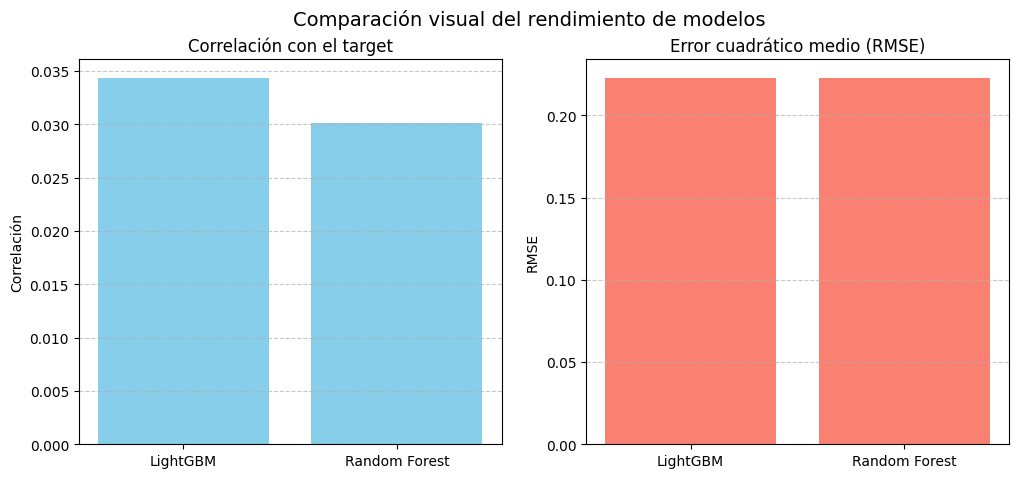

In [16]:
import matplotlib.pyplot as plt
import pandas as pd

# Guardar resultados en un DataFrame
results = pd.DataFrame({
    "Modelo": ["LightGBM", "Random Forest"],
    "Correlación": [corr, corr_rf],
    "RMSE": [rmse, np.sqrt(mean_squared_error(y_test, y_pred_rf))]
})

# Gráfico de comparación
fig, ax1 = plt.subplots(1, 2, figsize=(12, 5))

# Correlación
ax1[0].bar(results["Modelo"], results["Correlación"], color="skyblue")
ax1[0].set_title("Correlación con el target")
ax1[0].set_ylabel("Correlación")
ax1[0].grid(axis="y", linestyle="--", alpha=0.7)

# RMSE
ax1[1].bar(results["Modelo"], results["RMSE"], color="salmon")
ax1[1].set_title("Error cuadrático medio (RMSE)")
ax1[1].set_ylabel("RMSE")
ax1[1].grid(axis="y", linestyle="--", alpha=0.7)

plt.suptitle("Comparación visual del rendimiento de modelos", fontsize=14)
plt.show()


Podemos ver una mayor correlacion en LightGBM que en Random Forest

Ahora hagamos algunas predicciones con los datos de validación para evaluar el rendimiento de nuestro modelo.

## Evaluación del rendimiento:

La métrica de puntuación principal que usaremos se llama CORR (practica_corr), que es una variante específica de para este caso de uso del coeficiente de correlación de Pearson.

Esta métrica está diseñada para "alinear los incentivos" entre el modelo y el desempeño de un fondo de inversión. Es decir, un modelo con una buena puntuación CORR debería ayudar a un inversor a obtener buenos rendimientos.

In [17]:
from scipy import stats
import numpy as np

def practica_corr(preds, target):
    """Calcula una correlación robusta al estilo Numerai."""
    # Quita nulos
    mask = preds.notnull() & target.notnull()
    preds, target = preds[mask], target[mask]

    if len(preds) < 2 or preds.nunique() == 1 or target.nunique() == 1:
        return np.nan

    # Clasifica (manteniendo vínculos) y gaussianiza predicciones
    ranked_preds = (preds.rank(method="average").values - 0.5) / preds.count()
    gauss_ranked_preds = stats.norm.ppf(ranked_preds)

    # Centra los targets alrededor de 0
    centered_target = target - target.mean()

    # Exagera las colas (potencia 1.5)
    preds_p15 = np.sign(gauss_ranked_preds) * np.abs(gauss_ranked_preds) ** 1.5
    target_p15 = np.sign(centered_target) * np.abs(centered_target) ** 1.5

    # Correlación de Pearson final
    return np.corrcoef(preds_p15, target_p15)[0, 1]


##  Descarga de datos Validacion
Descargamos los archivos necesarios (entrenamiento y metadatos de características).

In [18]:
# Descarga el dataset de validación
napi.download_dataset(f"{DATA_VERSION}/validation.parquet")

#  Carga los datos de validación (solo filas tipo "validation")
validation = pd.read_parquet(
    f"{DATA_VERSION}/validation.parquet",
    columns=["era", "data_type", "target"] + feature_set
)
validation = validation[validation["data_type"] == "validation"]
del validation["data_type"]

# Reducir carga: usar solo 1 de cada 4 eras (puedes comentar si quieres usar todas)
validation = validation[validation["era"].isin(validation["era"].unique()[::4])]

# Embargo temporal (evita fuga de datos)
last_train_era = int(train["era"].unique()[-1])
eras_to_embargo = [str(era).zfill(4) for era in [last_train_era + i for i in range(4)]]
validation = validation[~validation["era"].isin(eras_to_embargo)]

# Predicciones de ambos modelos
validation["pred_lgb"] = model.predict(validation[feature_set])
validation["pred_rf"] = rf_model.predict(validation[feature_set])

# Correlación por era para cada modelo
per_era_corr = validation.groupby("era").apply(
    lambda x: pd.Series({
        "LightGBM": practica_corr(x["pred_lgb"], x["target"]),
        "RandomForest": practica_corr(x["pred_rf"], x["target"])
    })
)

per_era_corr.head()


2025-11-07 12:20:51,436 INFO numerapi.utils: target file already exists
2025-11-07 12:20:51,437 INFO numerapi.utils: starting download
v5.0/validation.parquet: 7.10GB [05:24, 21.9MB/s]                            
C:\Users\angel\AppData\Local\Temp\ipykernel_12424\29984772.py:25: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr = validation.groupby("era").apply(


,LightGBM,RandomForest
era,,
0579,0.009778,0.009706
0583,0.016676,-0.008772
0587,0.025118,0.019325
0591,0.008715,-0.014777
0595,0.028220,0.023480


Como se mencionó anteriormente, es importante calificar cada era histórica de forma independiente. Entonces, al evaluar el desempeño de nuestro modelo, deberíamos observar la corrección "por era".

Una cosa que puedes ver aquí es cómo de bajas son las puntuaciones (en el rango de +/- 5% de correlación). Esto es muy normal en el ámbito de las finanzas cuantitativas y es parte de la razón por la que se indica que es la "práctica de aprendizaje automático más difícil" del mundo.


C:\Users\angel\AppData\Local\Temp\ipykernel_12424\84513466.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Modelo", y="Correlación", data=melted_corr, palette="Set2")


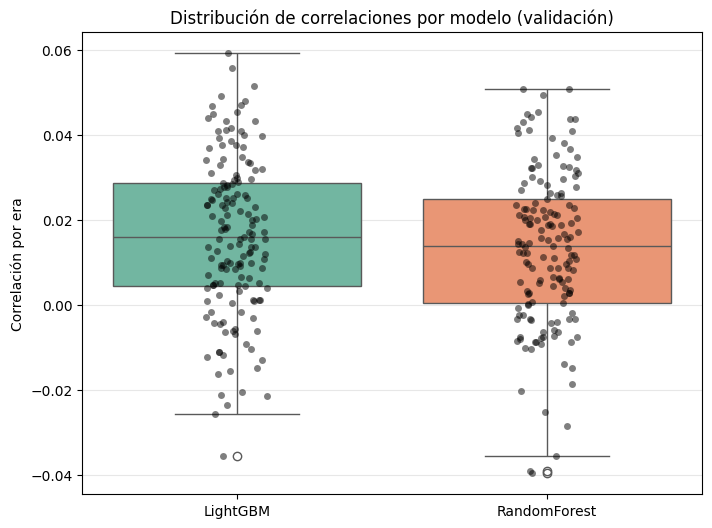

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

# Reestructura el DataFrame para graficar fácilmente
melted_corr = per_era_corr.reset_index().melt(id_vars="era", var_name="Modelo", value_name="Correlación")

plt.figure(figsize=(8,6))
sns.boxplot(x="Modelo", y="Correlación", data=melted_corr, palette="Set2")
sns.stripplot(x="Modelo", y="Correlación", data=melted_corr, color="black", alpha=0.5, jitter=True)

plt.title("Distribución de correlaciones por modelo (validación)")
plt.xlabel("")
plt.ylabel("Correlación por era")
plt.grid(axis="y", alpha=0.3)
plt.show()





En lugar de observar la puntuación "corr" de cada "era", resulta útil observar la puntuación "corr" acumulativa.

Esto se denomina "backtesting" en finanzas cuantitativas, donde las personas simulan el desempeño histórico de sus estrategias de inversión, puede considerar este gráfico como una prueba retrospectiva del desempeño de tu modelo durante el período de validación histórica.

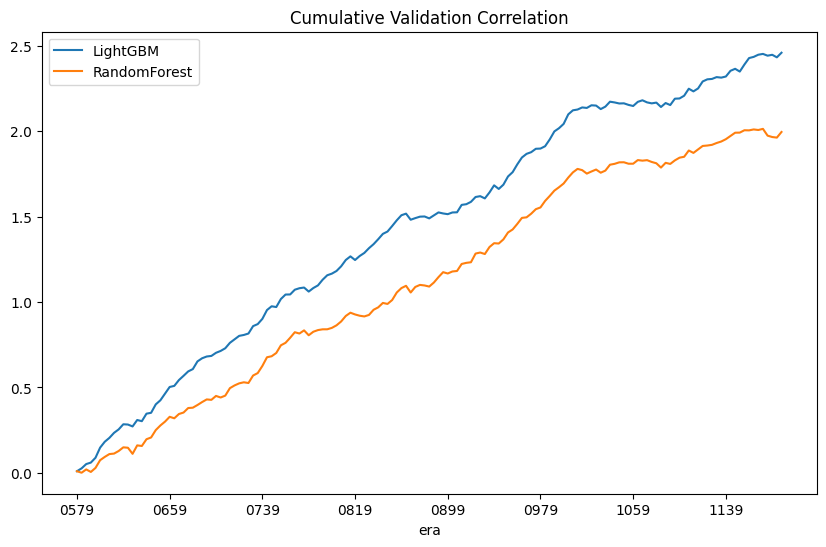

In [20]:
# Gráfica de la correlación acumulada por "era"
per_era_corr.cumsum().plot(kind="line", title="Cumulative Validation Correlation", figsize=(10, 6));

Métricas de rendimiento:
    
Para evaluar el rendimiento de nuestro modelo, también es útil calcular algunas métricas resumidas durante todo el período de validación.

La media de correlaciones es la medida principal del rendimiento de su modelo.

Sharpe es una medida de la coherencia de tu modelo, un concepto tomado de las finanzas, donde generalmente se refiere a los rendimientos ajustados al riesgo de una estrategia de inversión. Aquí calcularemos Sharpe como la correlación promedio dividida por la desviación estándar de las correlaciones.

La reducción máxima (max_drawdown) es una medida del riesgo de tu modelo, otro concepto tomado de las finanzas, donde generalmente se refiere a la pérdida financiera máxima sufrida por una estrategia de inversión. Aquí calcularemos la reducción máxima como la caída máxima desde el pico hasta el mínimo en la correlación de validación acumulativa.

In [21]:
# Cálculo de métricas por modelo
metrics_df = pd.DataFrame({
    "mean_corr": per_era_corr.mean(),
    "std_corr": per_era_corr.std(ddof=0),
})

metrics_df["sharpe_ratio"] = metrics_df["mean_corr"] / metrics_df["std_corr"]

# Drawdown máximo
cumulative = per_era_corr.cumsum()
rolling_max = cumulative.expanding(min_periods=1).max()
drawdown = rolling_max - cumulative
metrics_df["max_drawdown"] = drawdown.max()

# Limpieza y formato
metrics_df = metrics_df.round(4)
metrics_df


,mean_corr,std_corr,sharpe_ratio,max_drawdown
LightGBM,0.0161,0.0185,0.8680,0.0392
RandomForest,0.0130,0.0182,0.7185,0.0512


## Improvement & Investigation (2 puntos)

In [22]:
import numpy as np
import pandas as pd

def neutralize_per_era(df, feature_cols, pred_col="pred_lgb", proportion=1.0):
    df = df.copy()
    neutralized = []

    for era, data in df.groupby("era"):
        X = data[feature_cols].astype(np.float32).values
        y = data[pred_col].astype(np.float32).values
        X = (X - X.mean(axis=0)) / (X.std(axis=0) + 1e-6)
        y = y - y.mean()

        # Si hay pocas filas o features degeneradas, skip
        if X.shape[0] < X.shape[1]:
            neutralized.extend(y)  # no neutraliza, conserva
            continue

        # Usa regresión lineal eficiente (sin invertir matrices grandes)
        beta, *_ = np.linalg.lstsq(X, y, rcond=None)
        correction = X @ beta
        y_neutral = y - proportion * correction
        neutralized.extend(y_neutral / (np.std(y_neutral) + 1e-6))

    df[pred_col + "_neutral"] = neutralized
    return df



In [23]:
# Neutraliza tus predicciones de LightGBM respecto a todas las features
validation = neutralize_per_era(validation, feature_set, "pred_lgb")

# Evalúa de nuevo con tu métrica práctica
per_era_corr_neutral = validation.groupby("era").apply(
    lambda x: practica_corr(x["pred_lgb_neutral"], x["target"])
)

print("Correlación media original:", per_era_corr["LightGBM"].mean())
print("Correlación media neutralizada:", per_era_corr_neutral.mean())


Correlación media original: 0.016073384659113284
Correlación media neutralizada: 0.00948362847922273


C:\Users\angel\AppData\Local\Temp\ipykernel_12424\3066861548.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_neutral = validation.groupby("era").apply(


In [24]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0, random_state=42)
ridge_model.fit(X_train, y_train)
y_pred_ridge = ridge_model.predict(X_test)

corr_ridge = np.corrcoef(y_test, y_pred_ridge)[0,1]
print("Correlación Ridge:", corr_ridge)


Correlación Ridge: 0.029530865449264358


In [25]:
#  Correlación por era para los tres modelos
validation["pred_ridge"] = ridge_model.predict(validation[feature_cols])

per_era_corr = validation.groupby("era").apply(
    lambda x: pd.Series({
        "LightGBM": practica_corr(x["pred_lgb"], x["target"]),
        "RandomForest": practica_corr(x["pred_rf"], x["target"]),
        "Ridge": practica_corr(x["pred_ridge"], x["target"])
    })
)

per_era_corr.head()

C:\Users\angel\AppData\Local\Temp\ipykernel_12424\409748007.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr = validation.groupby("era").apply(


,LightGBM,RandomForest,Ridge
era,,,
0579,0.009778,0.009706,0.012930
0583,0.016676,-0.008772,0.028362
0587,0.025118,0.019325,0.031030
0591,0.008715,-0.014777,-0.005691
0595,0.028220,0.023480,0.037296


RESUMEN DE DATOS
Número de eras únicas: 153
Total de registros: 949,746
Número de features: 42
Promedio de registros por era: 6207.5
Mediana de registros por era: 6208.0

MÉTRICAS COMPARATIVAS ENTRE MODELOS:


,Mean Corr,Std Corr,Sharpe Ratio,Max Drawdown
LightGBM,0.0161,0.0185,0.8680,0.0392
RandomForest,0.0130,0.0182,0.7185,0.0512
Ridge,0.0125,0.0173,0.7230,0.0569


C:\Users\angel\AppData\Local\Temp\ipykernel_12424\3210117813.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Modelo", y="Correlación", data=melted_corr, palette="Set2", width=0.5)


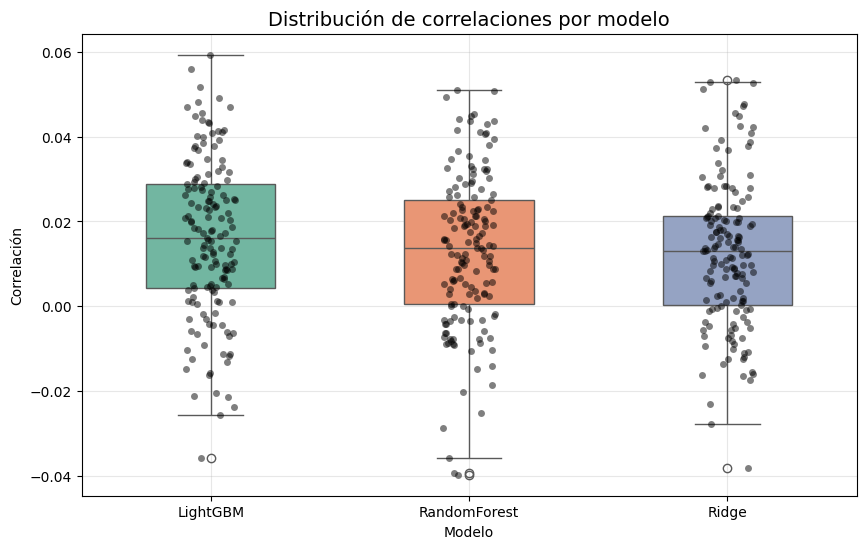

C:\Users\angel\AppData\Local\Temp\ipykernel_12424\3210117813.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metricas_df.index, y=metricas_df[col], palette="Set2", ax=axes[i])
C:\Users\angel\AppData\Local\Temp\ipykernel_12424\3210117813.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metricas_df.index, y=metricas_df[col], palette="Set2", ax=axes[i])
C:\Users\angel\AppData\Local\Temp\ipykernel_12424\3210117813.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metricas_df.index, y=metricas_df[col], palette="Set2", ax=axes[i]

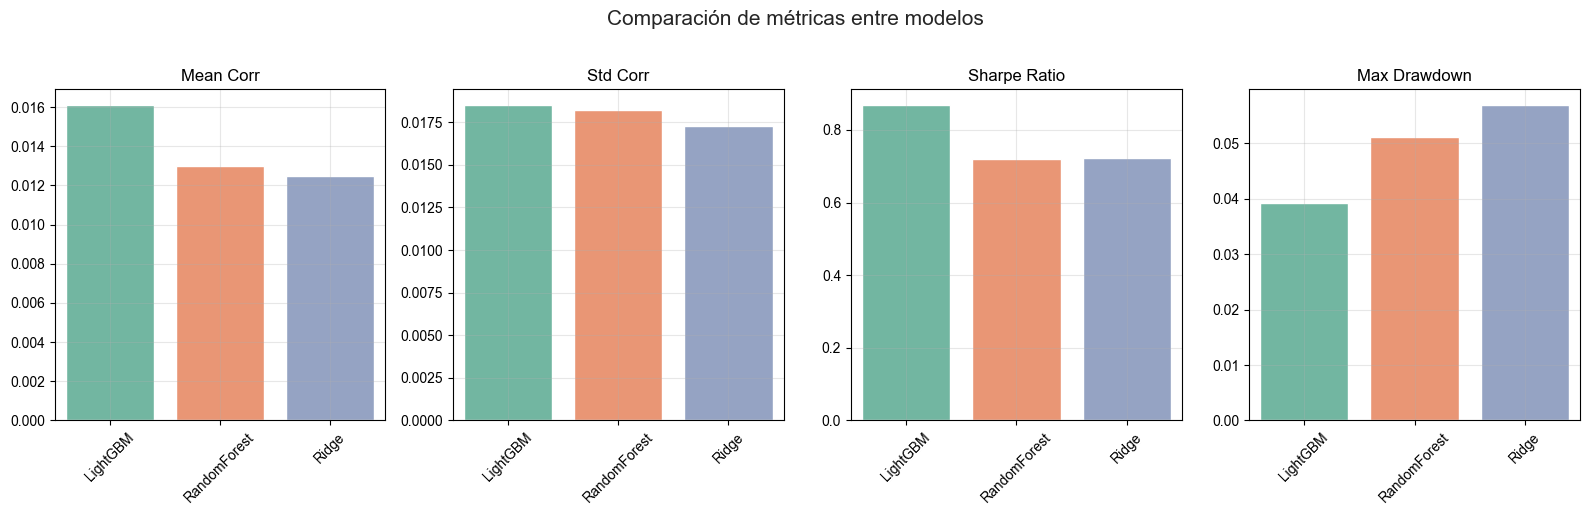

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np


# RESUMEN DE DATOS
print("RESUMEN DE DATOS")
print(f"Número de eras únicas: {validation['era'].nunique()}")
print(f"Total de registros: {len(validation):,}")
print(f"Número de features: {len(feature_set)}")
print(f"Promedio de registros por era: {validation.groupby('era').size().mean():.1f}")
print(f"Mediana de registros por era: {validation.groupby('era').size().median():.1f}")
print()

#  MÉTRICAS DE RENDIMIENTO
corr_mean = per_era_corr.mean()
corr_std = per_era_corr.std(ddof=0)
corr_sharpe = corr_mean / corr_std
max_drawdown = (per_era_corr.cumsum().expanding(min_periods=1).max() - per_era_corr.cumsum()).max()

metricas_df = pd.DataFrame({
    "Mean Corr": corr_mean,
    "Std Corr": corr_std,
    "Sharpe Ratio": corr_sharpe,
    "Max Drawdown": max_drawdown
}).round(4)

print("MÉTRICAS COMPARATIVAS ENTRE MODELOS:")
display(metricas_df)



# --- Distribución de correlaciones ---
melted_corr = per_era_corr.reset_index().melt(
    id_vars="era", var_name="Modelo", value_name="Correlación"
)

plt.figure(figsize=(10,6))
sns.boxplot(x="Modelo", y="Correlación", data=melted_corr, palette="Set2", width=0.5)
sns.stripplot(x="Modelo", y="Correlación", data=melted_corr, color="black", alpha=0.5, jitter=True)
plt.title("Distribución de correlaciones por modelo", fontsize=14)
plt.grid(alpha=0.3)
plt.show()
fig, axes = plt.subplots(1, 4, figsize=(16,5))
sns.set_style("whitegrid")

for i, col in enumerate(metricas_df.columns):
    sns.barplot(x=metricas_df.index, y=metricas_df[col], palette="Set2", ax=axes[i])
    axes[i].set_title(col, fontsize=12)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(alpha=0.3)

fig.suptitle("Comparación de métricas entre modelos", fontsize=15, y=1.02)
plt.tight_layout()


Estas métricas de rendimiento anteriores no son sorprendentes, pero son lo suficientemente buenas como para comenzar!

SUBMISSIONS

Vamos a evaluar los modelos según su rendimiento en vivo!

La tarea es generar predicciones sobre valores objetivo desconocidos, que representan los rendimientos del mercado de valores dentro de X días.

In [27]:
# Descargar las últimas entradas en tiempo real
napi.download_dataset(f"{DATA_VERSION}/live.parquet")

# Carga dichas características
live_features = pd.read_parquet(f"{DATA_VERSION}/live.parquet", columns=feature_set)

# Genera predicciones en vivo
live_predictions = model.predict(live_features[feature_set])

#Evaluar
live_predictions

# Envío
pd.Series(live_predictions, index=live_features.index).to_frame("prediction")

2025-11-07 12:27:02,945 INFO numerapi.utils: target file already exists
2025-11-07 12:27:02,947 INFO numerapi.utils: starting download
v5.0/live.parquet: 16.8MB [00:03, 4.49MB/s]                   


,prediction
id,
n0022ea68a1e38fc,0.505498
n0035a68ec0cb755,0.504962
n0038a969a400336,0.503531
n003a6a571877c7c,0.514661
n003c6e8f8fd0984,0.483534
...,...
nffe080948a224bf,0.496890
nffe4addf39fc75e,0.491848
nffec427febcb228,0.505842
